<a href="https://colab.research.google.com/github/emissilva/challenge-clickbus/blob/main/scripts/analises/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [14]:
df = pd.read_csv('/content/resultado_p1_2022.csv')
df

,fk_contact,recency,frequency,monetary
0,cliente_10,320,3,593.43
1,cliente_100,5,13,683.28
2,cliente_1000,13,1,201.00
3,cliente_100002,115,1,60.30
4,cliente_100006,68,2,356.35
...,...,...,...,...
166137,cliente_99987,299,2,429.30
166138,cliente_9999,2,1,73.73
166139,cliente_99990,214,1,212.38
166140,cliente_99991,211,1,93.81


In [15]:
zero_counts = df.eq(0).sum()
print(zero_counts)

fk_contact    0
recency       0
frequency     0
monetary      0
dtype: int64


In [16]:
features = df[['recency', 'frequency', 'monetary']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [19]:
# Aplicar o PCA para reduzir as dimensões
# Reduz as features para 2 componentes principais
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# 4. Criar um novo DataFrame com os componentes
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# 5. Analisar o resultado
print("Dados originais:\n", df.head())
print("\nDados após o PCA:\n", pca_df.head())
print("\nVariância explicada por cada componente:")
print(pca.explained_variance_ratio_)

Dados originais:
        fk_contact  recency  frequency  monetary
0      cliente_10      320          3    593.43
1     cliente_100        5         13    683.28
2    cliente_1000       13          1    201.00
3  cliente_100002      115          1     60.30
4  cliente_100006       68          2    356.35

Dados após o PCA:
         PC1       PC2
0 -0.101572  1.437914
1  2.082053 -1.005341
2  0.001730 -1.314086
3 -0.288891 -0.465453
4  0.128025 -0.790012

Variância explicada por cada componente:
[0.61607688 0.31870825]


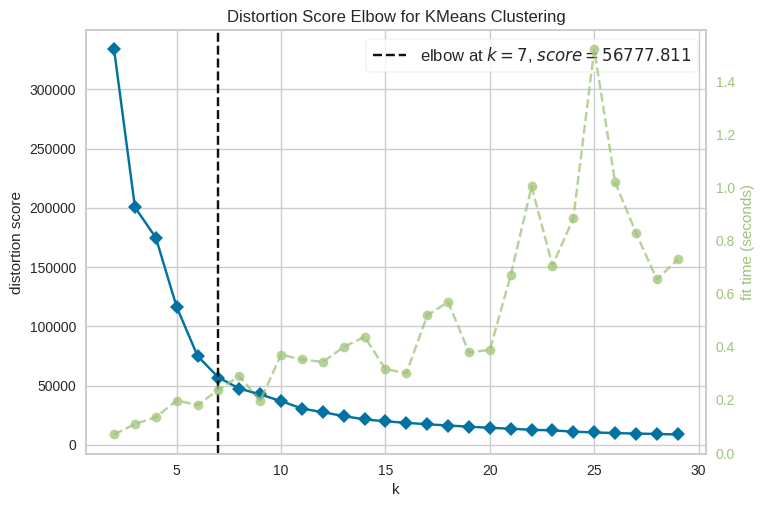

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
model = KMeans(random_state=42, n_init='auto')
visualizer_inertia = KElbowVisualizer(model, k=(2, 30), metric='distortion')
visualizer_inertia.fit(principal_components)
visualizer_inertia.show()

In [ ]:
visualizer_silhouette = KElbowVisualizer(model, k=(2, 30), metric='silhouette')
visualizer_silhouette.fit(principal_components)
visualizer_silhouette.show()